# PBMC 68k Figures

In [10]:
import sys
sys.path.append('../')
from clim import ClusterLOCOMP, ClusterLOCO_RAMPART, hinge_error
from benchmarking import LRP_score, c_SHAP, PBFI, feature_imp_cluster
from clim.utils.utils import match_labels

In [11]:
import scanpy as sc
import numpy as np
adata = sc.datasets.pbmc68k_reduced()
X = np.asarray(adata.X)

In [12]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)

## Cluster-level analysis

### Run models

Run file under `simulations/scripts/PBMC68k_models.py` to obtain the results for the following.

### Figures

In [25]:
import pickle

with open('./models/pbmc68k_results_K10_rampart_100.pkl', 'rb') as file:
    data = pickle.load(file)
    
with open('./models/pbmc68k/pbmc68k_results_KMeans_K10.pkl', 'rb') as file:
    lrp = pickle.load(file)

with open('./models/pbmc68k/pbmc68k_results_HC_K10.pkl', 'rb') as file:
    cloco = pickle.load(file)
    
data.keys(), lrp.keys(), cloco['cluster_loco'].keys()

/Users/clairehe/anaconda3/envs/ficluster/lib/python3.12/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator AgglomerativeClustering from version 1.8.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


ModuleNotFoundError: No module named 'clim.minipatches.fast_g'

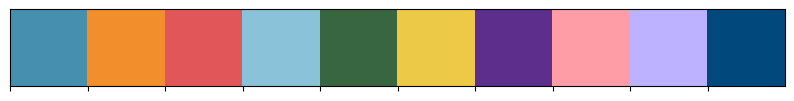

In [26]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import numpy as np

palette = [
    "#468faf",  # blue
    "#F28E2B",  # orange
    "#E15759",  # red
    "#89c2d9",  # teal
    "#386641",  # green
    "#EDC948",  # yellow
    "#5d2e8c",  # purple
    "#FF9DA7",  # pink
    "#bdb2ff",  # lavender
    "#01497c",  # dark blue
    "#a7c957",  # light green
    "#D37295"   # magenta
]

K = 10

palette = palette[:K]
cmap = ListedColormap(palette)
norm = BoundaryNorm(np.arange(K + 1) - 0.5, K)

sns.palplot(palette)

In [27]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(8,3))
codes = data["data"]["label_codes"]
names = data["data"]["label_names"]   # or whatever key stores list(cat.categories)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=codes, cmap=cmap, alpha=0.8)
handles, _ = scatter.legend_elements()
plt.legend( handles, names, title="Label", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

NameError: name 'data' is not defined

<Figure size 800x300 with 0 Axes>

In [47]:
from sklearn.cluster import AgglomerativeClustering, KMeans
adata.obs['km_labels'] = pd.Categorical(match_labels(pd.Categorical(adata.obs['bulk_labels']).codes, KMeans(n_clusters=K).fit_predict(adata.X)))
adata.obs['hc_labels'] = pd.Categorical(match_labels(pd.Categorical(adata.obs['bulk_labels']).codes, AgglomerativeClustering(n_clusters=K, linkage='ward').fit_predict(adata.X)))


In [48]:
old_col = "bulk_labels"
new_col = "bulk_labels_short"

old_categories = list(adata.obs[old_col].cat.categories)

name_map = {
    "CD4+/CD45RA+/CD25- Naive T": "Naive CD4 T",
    "CD4+/CD45RO+ Memory": "Memory CD4 T",
    "CD8+/CD45RA+ Naive Cytotoxic": "Naive CD8 T",
    "CD8+ Cytotoxic T": "CD8 T",
    "CD56+ NK": "NK",
    "CD19+ B": "B",
    "CD14+ Monocyte": "Monocyte",
    "CD34+": "CD34",
    "Dendritic": "Dendritic",
    "CD4+/CD25 T Reg": "T reg",
}

short_categories = [
    name_map.get(cat, cat)
    for cat in old_categories
]

adata.obs[new_col] = (
    adata.obs[old_col]
    .astype(str)
    .map(name_map)
    .fillna(adata.obs[old_col].astype(str))
)

adata.obs[new_col] = pd.Categorical(
    adata.obs[new_col],
    categories=short_categories,
    ordered=True
)

In [49]:
adata.obs['bulk_labels_codes'] = pd.Categorical(pd.Categorical(adata.obs['bulk_labels']).codes)

In [55]:
adata.obs['bulk_labels'].cat.categories

Index(['CD4+/CD25 T Reg', 'CD4+/CD45RA+/CD25- Naive T', 'CD4+/CD45RO+ Memory',
       'CD8+ Cytotoxic T', 'CD8+/CD45RA+ Naive Cytotoxic', 'CD14+ Monocyte',
       'CD19+ B', 'CD34+', 'CD56+ NK', 'Dendritic'],
      dtype='object')

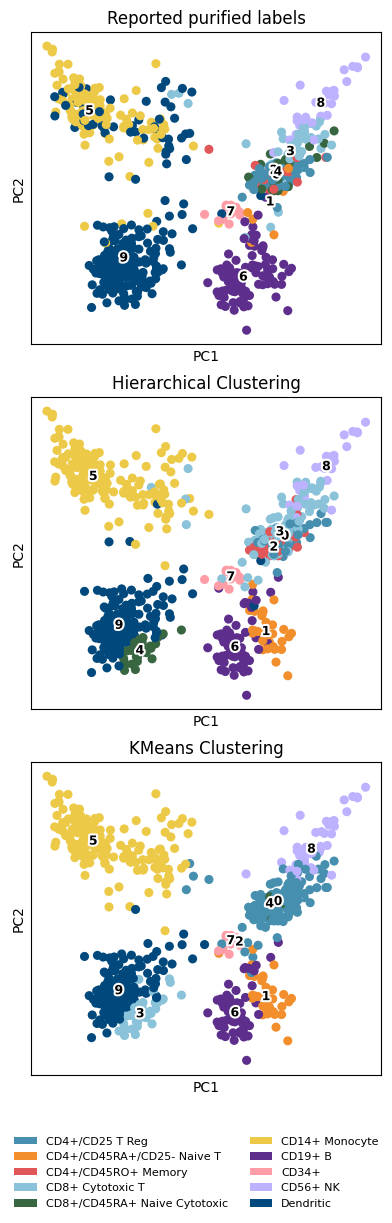

In [64]:
from matplotlib.patches import Patch
fig, axes = plt.subplots(3, 1, figsize=(4, 12), sharex=True, sharey=True)

plot_specs = [
    ("bulk_labels_codes", "Reported purified labels"),
    ("hc_labels", "Hierarchical Clustering"),
    ("km_labels", "KMeans Clustering"),
]

for ax, (label_col, title) in zip(axes, plot_specs):
    sc.pl.pca(
        adata,
        color=label_col,
        palette=palette,
        ax=ax,
        show=False,
        legend_loc="on data",
        legend_fontsize=9,
        legend_fontoutline=3,
        title=title,
        frameon=True,
    )
cats = adata.obs["bulk_labels_codes"].cat.categories
names = adata.obs['bulk_labels'].cat.categories
handles = [
    Patch(
        facecolor=palette[int(cat)],
        edgecolor="none",
        label=names[int(cat)]
    )
    for cat in cats
]

fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
    fontsize=8,
)
fig.tight_layout()
fig.subplots_adjust(bottom=0.1)  # reserve space for bottom legend
fig.savefig(
    "../figures/pca_aligned_labels.pdf",
    bbox_inches="tight",
    pad_inches=0.05,
    dpi=300
)

In [23]:
cell_types_cdict = {
    names[i]: palette[i]
    for i in range(len(names))
}

NameError: name 'names' is not defined

In [21]:
# load markers
df = pd.read_csv('./data/full_marker_list_hand.csv')

In [83]:
import matplotlib.colors as mcolors
import numpy as np

def average_hex_colors(hex_list):
    """Calculates the average color of a list of hex strings."""
    if not hex_list:
        return "#adb5bd"  # Default dark gray
    rgbs = [mcolors.to_rgb(c) for c in hex_list]
    avg_rgb = np.mean(rgbs, axis=0)
    return mcolors.to_hex(avg_rgb)


def normalize(x):
    return (x - np.min(x))/(np.max(x)-np.min(x))
    
def plot_clusterwise_scores_df(df_scores, original_id, aligned_id, relevant_markers, cell_types_cdict, top_k=10, ax=None):
    """
    Plots the top important genes for a cluster using color-averaging for multi-marker genes.
    relevant_markers: pandas DataFrame with ['Cell type', 'Gene']
    """
    column_label = f"Cluster {original_id}"
    if column_label not in df_scores.columns:
        print(f"Warning: {column_label} not found in DataFrame.")
        return

    # 1. Pre-calculate the average color for every gene in the reference
    relevant_markers['color_val'] = relevant_markers['Cell type'].map(cell_types_cdict).fillna("#adb5bd")
    gene_color_map = relevant_markers.groupby('Gene')['color_val'].apply(lambda x: average_hex_colors(list(x))).to_dict()

    # 2. Get the top genes for this cluster
    series = df_scores[column_label].sort_values(ascending=False)
    top_genes = series.head(top_k)[::-1]  # Reverse for horizontal bar plot
    
    # 3. Assign colors to the bars (averaged if the gene is a marker for multiple types)
    default_color = "#adb5bd"
    bar_colors = [gene_color_map.get(g, default_color) for g in top_genes.index]

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    
    ax.barh(top_genes.index, normalize(top_genes.values), color=bar_colors)
    
    ax.set_title(f" Cluster {aligned_id}", fontsize=14)
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
    
    # 4. Color the tick labels by the same averaged color logic
    for tick_label, gene in zip(ax.get_yticklabels(), top_genes.index):
        color = gene_color_map.get(gene, default_color)
        tick_label.set_color(color)
        tick_label.set_fontsize(10)
        tick_label.set_fontweight('bold')


In [335]:
def make_gene_style_map(
    relevant_markers,
    cell_types_cdict,
    cluster_cell_type=None,
    gene_col="Gene",
    cell_type_col="Cell type",
    default_color="#adb5bd",
    hatch_patterns=None
):
    """
    Build gene -> plotting style map.

    Base color is forced to the aligned cluster cell-type color.
    Marker ambiguity is shown as colored hatch overlays.
    """
    if hatch_patterns is None:
        hatch_patterns = ["////", "\\\\", "......", "---", "xxxx", "+++++"]

    markers = relevant_markers.copy()

    markers["color_val"] = (
        markers[cell_type_col]
        .map(cell_types_cdict)
        .fillna(default_color)
    )

    cluster_color = (
        cell_types_cdict.get(cluster_cell_type, default_color)
        if cluster_cell_type is not None
        else default_color
    )

    gene_style_map = {}

    for gene, sub in markers.groupby(gene_col):
        sub_unique = (
            sub[[cell_type_col, "color_val"]]
            .drop_duplicates()
            .reset_index(drop=True)
        )

        cell_types = sub_unique[cell_type_col].tolist()
        colors = sub_unique["color_val"].tolist()

        # Hatches show marker identities that are NOT the aligned cluster label
        hatch_records = [
            (cell_type, color)
            for cell_type, color in zip(cell_types, colors)
            if cell_type != cluster_cell_type
        ]

        gene_style_map[gene] = {
            "base_color": cluster_color,
            "is_multi": len(cell_types) > 1,
            "is_marker_for_cluster": cluster_cell_type in cell_types,
            "cluster_cell_type": cluster_cell_type,
            "cell_types": cell_types,
            "colors": colors,
            "hatch_overlays": [
                {
                    "hatch": hatch_patterns[i % len(hatch_patterns)],
                    "color": color,
                    "cell_type": cell_type,
                }
                for i, (cell_type, color) in enumerate(hatch_records)
            ],
        }

    return gene_style_map

In [258]:
def plot_clusterwise_scores_df(
    df_scores,
    original_id,
    aligned_id,
    relevant_markers,
    cell_types_cdict,
    top_k=10,
    ax=None,
    default_color="#adb5bd",
    show_multi_marker_star=True,
    normalize_values=True,
    hatch_patterns=None,
    aligned_id_to_name=None
):
    """
    Plot top genes for a cluster.

    Multi-cell-type marker genes are shown with colored hatch overlays.

    aligned_id_to_name:
        dict mapping aligned cluster IDs to cell-type names, e.g.
        {0: "T cell", 1: "B cell"}
    """
    column_label = f"Cluster {original_id}"

    if column_label not in df_scores.columns:
        print(f"Warning: {column_label} not found in DataFrame.")
        return None
    cluster_cell_type = names[aligned_id] if names is not None else None
    gene_style_map = make_gene_style_map(
        relevant_markers=relevant_markers,
        cell_types_cdict=cell_types_cdict,
        cluster_cell_type=cluster_cell_type,
        gene_col="Gene",
        cell_type_col="Cell type",
        default_color=default_color,
        hatch_patterns=hatch_patterns
    )

    series = df_scores[column_label].dropna().sort_values(ascending=False)
    top_genes = series.head(top_k)[::-1]

    genes = top_genes.index.astype(str).to_numpy()
    values = top_genes.values.astype(float)

    if normalize_values:
        plot_values = normalize(values)
    else:
        plot_values = values

    styles = [
        gene_style_map.get(
            gene,
            {
                "base_color": default_color,
                "is_multi": False,
                "cell_types": [],
                "colors": [default_color],
                "hatch_overlays": [],
            }
        )
        for gene in genes
    ]

    bar_colors = [style["base_color"] for style in styles]

    display_genes = [
        f"{gene} *" if style["is_multi"] and show_multi_marker_star else gene
        for gene, style in zip(genes, styles)
    ]

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    ypos = np.arange(len(display_genes))

    ax.barh(
        ypos,
        plot_values,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.6
    )

    # Colored hatch overlays for ambiguous genes
    for y, value, style in zip(ypos, plot_values, styles):
        for overlay in style["hatch_overlays"]:
            ax.barh(
                y,
                value,
                color="none",
                edgecolor=overlay["color"],
                hatch=overlay["hatch"],
                linewidth=0.0
            )

    ax.set_yticks(ypos)
    ax.set_yticklabels(display_genes)

    # ------------------------------------------------------------
    # Cluster title color based on aligned_id
    # ------------------------------------------------------------
    if aligned_id_to_name is not None:
        aligned_name = aligned_id_to_name.get(aligned_id, f"Cluster {aligned_id}")
    else:
        aligned_name = f"Cluster {aligned_id}"

    title_color = cell_types_cdict.get(aligned_name, "black")

    ax.set_title(
        aligned_name,
        fontsize=14,
        color=title_color,
        fontweight="bold"
    )

    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

    for tick_label, style in zip(ax.get_yticklabels(), styles):
        tick_label.set_color(style["base_color"])
        tick_label.set_fontsize(10)
        tick_label.set_fontweight("bold")

    return ax

In [259]:
lrp_scores = pd.DataFrame(lrp['lrp']['raw_delta'].T, columns = [f'Cluster {i}' for i in range(10)], index=adata.var_names)
print(lrp_scores.shape)

(765, 10)


In [260]:
lrp_scores.head() # using cluster numerotation from before alignment!! raw clusters

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9
index,,,,,,,,,,
HES4,0.000305,0.000043,0.000303,0.000273,0.031092,0.000105,0.000462,0.000320,0.000740,0.000020
TNFRSF4,0.001424,0.000024,0.000579,0.000045,0.000342,0.000018,0.001354,0.000470,0.000597,0.000015
SSU72,0.000212,0.005144,0.000691,0.002969,0.001118,0.000005,0.001636,0.001895,0.000170,0.001134
PARK7,0.001790,0.000071,-0.001076,0.001133,0.001758,0.007385,0.002332,0.000514,0.006269,0.000774
RBP7,0.000028,0.000003,0.000027,0.000026,0.002860,0.000009,0.000042,0.000029,0.000094,0.000002


In [328]:
mapping, lrp_aligned = match_labels(codes, lrp['lrp']['raw_labels'], return_map=True)

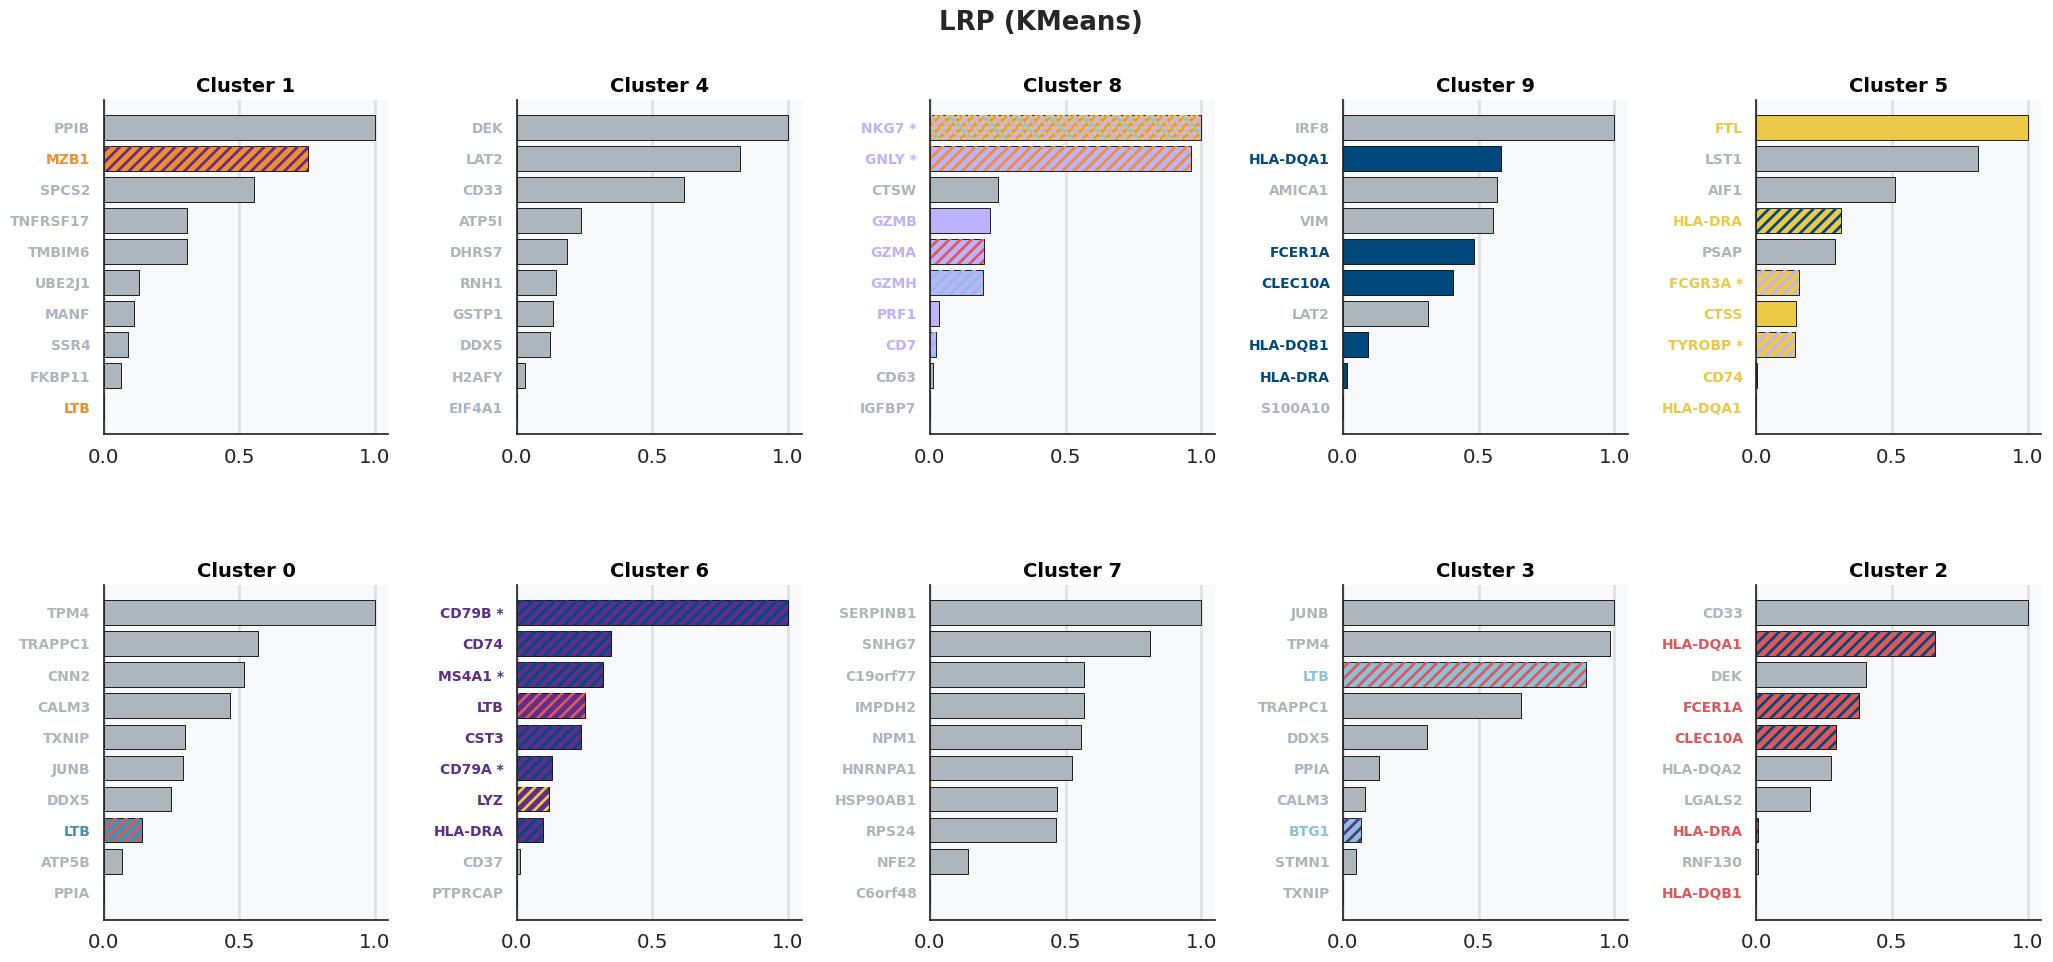

In [329]:
fig, ax = plt.subplots(2, K//2, figsize=(25,10))
ax= ax.flatten()
for k in range(K):
    aligned_k = mapping[k]
    plot_clusterwise_scores_df(lrp_scores, k, aligned_k, df, cell_types_cdict, top_k=10, ax=ax[k], hatch_patterns =  ["///", "\\", "...", "---", 'xxxx', '+++++'])

fig.suptitle('LRP (KMeans)', fontweight='bold', y=1.02)
fig.subplots_adjust(
    wspace=0.45,
    hspace=0.45,
    top=0.93
)
fig.savefig('../figures/lrp_clusterwise_scores_full.pdf',bbox_inches='tight')

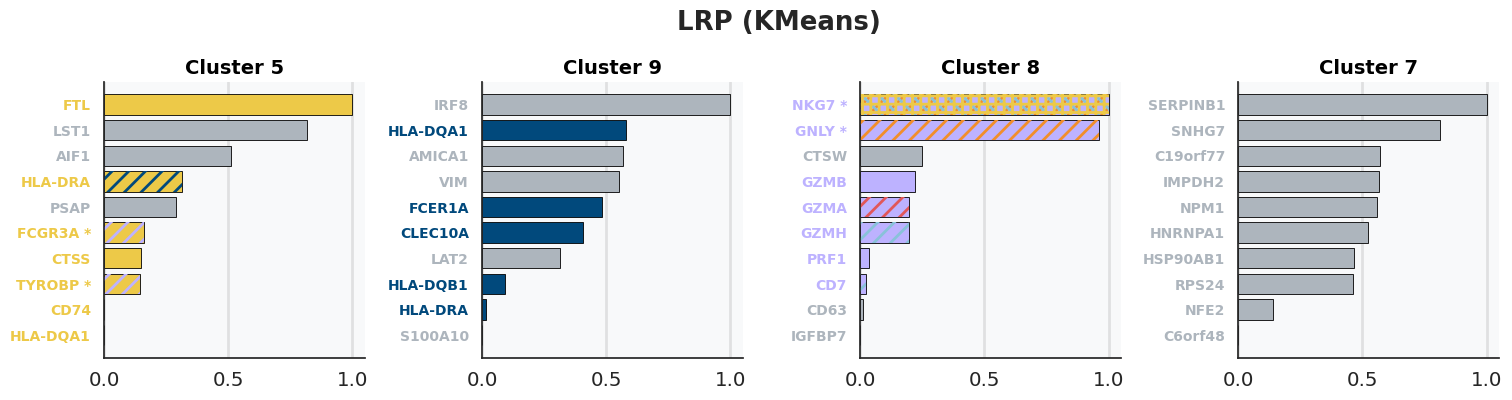

In [330]:
import matplotlib
matplotlib.rcParams["hatch.linewidth"] = 2.0  
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
# select 5, 9 and 8 and 7
select_k = [4, 3, 2, 7]
for i, k in enumerate(select_k):
    aligned_k = mapping[k]
    plot_clusterwise_scores_df(lrp_scores, k, aligned_k, df, cell_types_cdict, top_k=10, ax=ax[i], hatch_patterns =  ["//", "\\\\", "++", "..", 'xxxx', '+++++'])
fig.suptitle('LRP (KMeans)', fontweight='bold')
fig.subplots_adjust(wspace=0.45, top=0.8) 
fig.savefig('../figures/lrp_clusterwise_scores.pdf',bbox_inches='tight')

In [331]:
cloco_scores = pd.DataFrame(cloco['cluster_loco']['delta_by_cluster'], columns = [f"Cluster {cloco['cluster_loco']['clusters'][i]}" for i in range(K)], index=adata.var_names)
print(cloco_scores.shape)
mapping, cloco_aligned = match_labels(codes, cloco['cluster_loco']['consensus_labels'], return_map=True)
cloco_scores.head()

(765, 10)


,Cluster 0,Cluster 3,Cluster 1,Cluster 6,Cluster 4,Cluster 8,Cluster 7,Cluster 9,Cluster 2,Cluster 5
index,,,,,,,,,,
HES4,0.001153,-0.000512,-0.001556,0.001583,-0.000013,0.001796,-0.001349,0.000930,0.000424,-0.000811
TNFRSF4,0.000337,-0.000380,-0.000942,0.000279,-0.001092,-0.000231,-0.000281,-0.000911,0.000646,-0.000158
SSU72,-0.000716,0.000127,-0.000722,-0.000178,0.001559,-0.000171,-0.002520,0.000031,-0.000511,-0.000432
PARK7,-0.000845,0.001461,-0.001268,0.000153,-0.000686,-0.001043,-0.003129,0.000121,-0.001148,-0.001257
RBP7,-0.001346,-0.001610,-0.000481,0.001045,-0.000212,0.001783,-0.001157,-0.000568,-0.001675,-0.000074


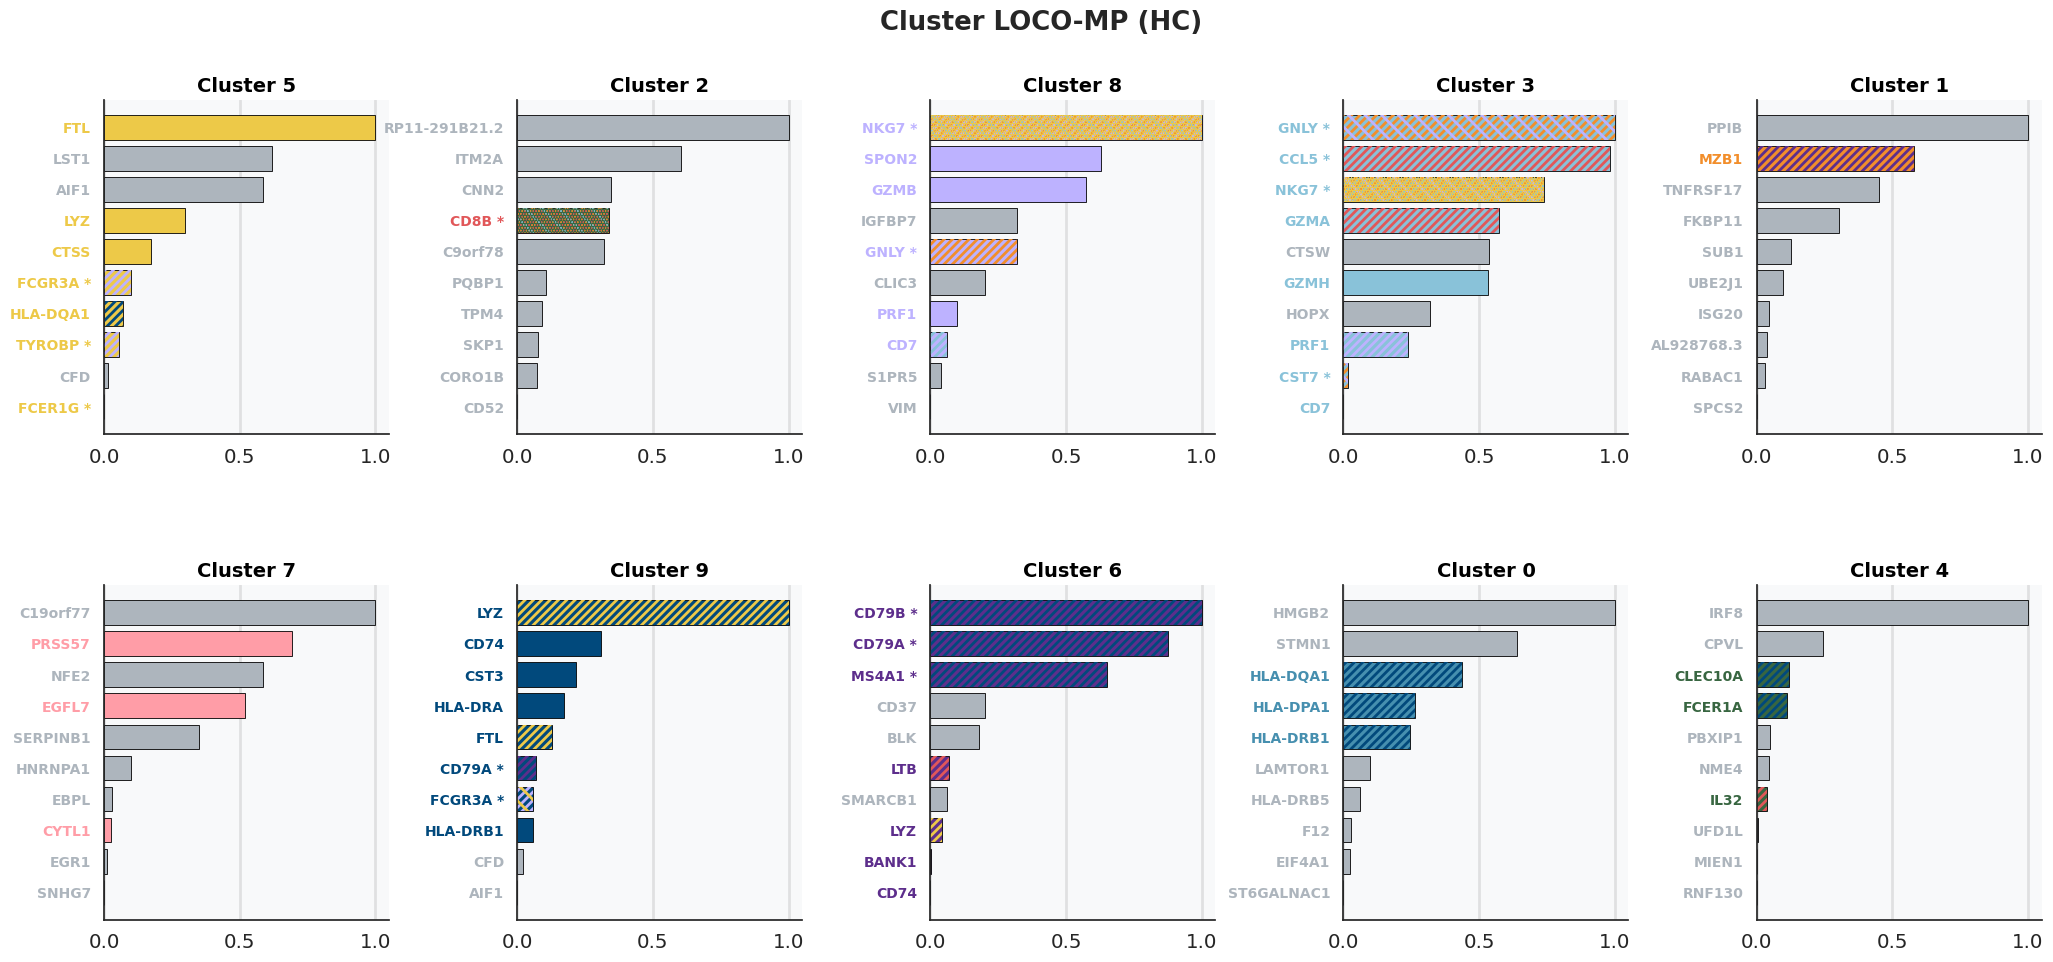

In [332]:
fig, ax = plt.subplots(2, K//2, figsize=(25,10))
ax = ax.flatten()
for k in range(K):
    aligned_k = mapping[k]
    plot_clusterwise_scores_df(cloco_scores, k, aligned_k, df, cell_types_cdict, top_k=10, ax=ax[k])

fig.suptitle('Cluster LOCO-MP (HC)', fontweight='bold', y= 1.02)
fig.subplots_adjust(
    wspace=0.45,
    hspace=0.45,
    top=0.93
)

fig.savefig('../figures/cloco_clusterwise_scores_full.pdf',bbox_inches='tight')

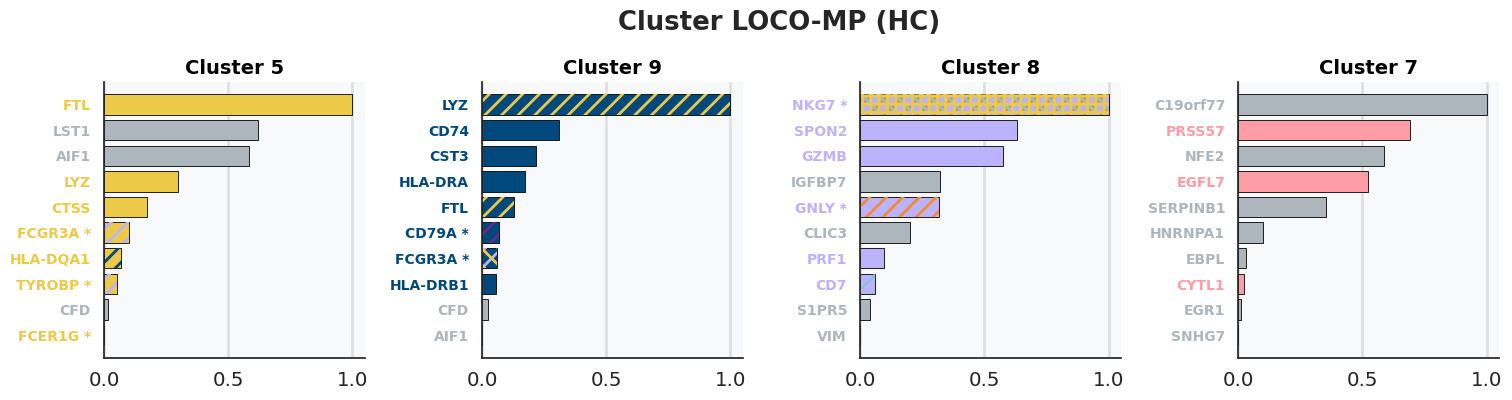

In [333]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
# select 5, 9 and 8 and 7
select_k = [0, 6, 2, 5]
for i, k in enumerate(select_k):
    aligned_k = mapping[k]
    plot_clusterwise_scores_df(cloco_scores, k, aligned_k, df, cell_types_cdict, top_k=10, ax=ax[i],hatch_patterns =  ["//", "\\\\", "++", "..", 'xxxx', '+++++'])

fig.suptitle('Cluster LOCO-MP (HC)', fontweight='bold')
fig.subplots_adjust(wspace=0.45, top=0.8) 
fig.savefig('../figures/cloco_clusterwise_scores.pdf',bbox_inches='tight')

In [274]:
sc.tl.rank_genes_groups(adata, 'louvain', method='t-test',corr_method='benjamini-hochberg')
louvain_scores = sc.get.rank_genes_groups_df(adata, group=None).sort_values(['group','scores'], ascending=True).pivot(index='names', columns='group',values='scores')
louvain_scores.columns = [f'Cluster {i}' for i in range(11)]

In [276]:
louvain_scores.head()

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10
names,,,,,,,,,,,
ABHD17A,-0.291986,-3.292760,-0.481859,4.657989,0.151403,0.386104,-1.340964,-4.557531,-5.243863,-0.945549,-0.960774
ABI1,0.982054,-1.411738,0.241031,-0.604195,2.370436,-3.566878,-0.406920,-0.410377,0.036594,0.818756,-0.077052
ABI3,-13.638267,16.823889,1.490762,0.063874,-14.023966,4.641376,0.638559,-3.859176,-9.396644,-2.893677,-22.258020
AC079767.4,-0.756430,-4.474951,-4.474190,-4.468747,4.608749,-4.467079,-0.478411,-4.465205,-4.464825,-4.463710,-4.463168
AC084018.1,0.609261,-0.244186,-0.761970,1.062518,-2.387718,0.155171,-1.181804,-0.696294,0.756200,0.779741,0.135668


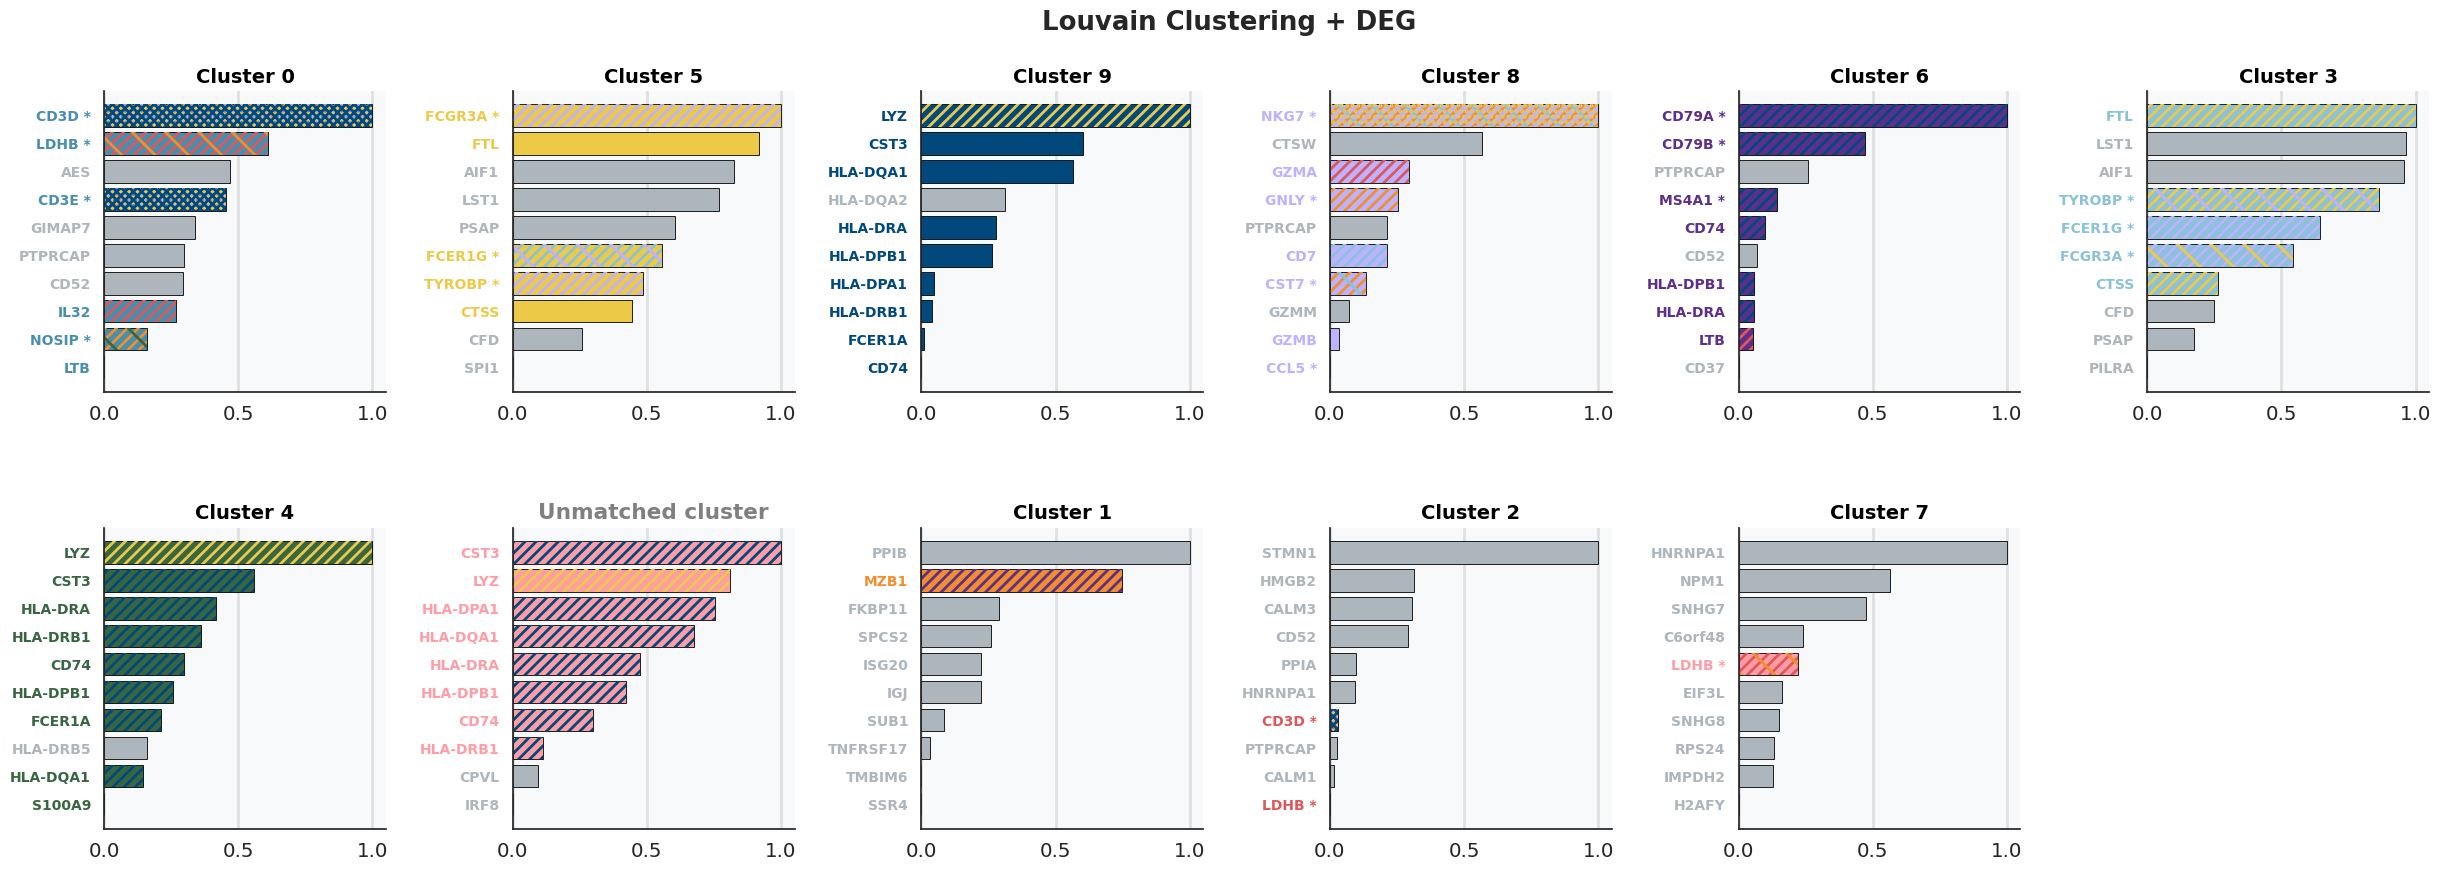

In [321]:
import math
import matplotlib.pyplot as plt

# Match Louvain clusters to reference codes
louvain_codes = pd.Categorical(adata.obs["louvain"]).codes
mapping, louvain_aligned = match_labels(
    codes,
    louvain_codes,
    return_map=True
)

# Number of Louvain clusters, not reference clusters
n_louvain_clusters = len(np.unique(louvain_codes))
n_reference_clusters = len(np.unique(codes))

# Dynamic grid
ncols = 6
nrows = math.ceil(n_louvain_clusters / ncols)

fig, ax = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 4.5 * nrows)
)

ax = np.asarray(ax).flatten()

for k in range(n_louvain_clusters):
    aligned_k = mapping.get(k, None) if isinstance(mapping, dict) else mapping[k]

    if aligned_k is not None and aligned_k < n_reference_clusters:
        plot_clusterwise_scores_df(
            louvain_scores,
            original_id=k,
            aligned_id=aligned_k,
            relevant_markers=df,
            cell_types_cdict=cell_types_cdict,
            top_k=10,
            ax=ax[k],
            hatch_patterns=["///", "\\", "...", "---", "xxxx", "+++++"]
        )
    else:
        # Still show the cluster, but mark as unmatched
        plot_clusterwise_scores_df(
            louvain_scores,
            original_id=k,
            aligned_id=k,
            relevant_markers=df,
            cell_types_cdict=cell_types_cdict,
            top_k=10,
            ax=ax[k],
            hatch_patterns=["///", "\\", "...", "---", "xxxx", "+++++"]
        )
        ax[k].set_title(f"Unmatched cluster", color="gray", fontweight="bold")

# Hide unused axes
for j in range(n_louvain_clusters, len(ax)):
    ax[j].axis("off")

fig.suptitle(
    "Louvain Clustering + DEG",
    fontweight="bold",
    y=1.02
)

fig.subplots_adjust(
    wspace=0.45,
    hspace=0.45,
    top=0.93
)

fig.savefig(
    "../figures/louvain_clusterwise_scores_full.pdf",
    bbox_inches="tight"
)

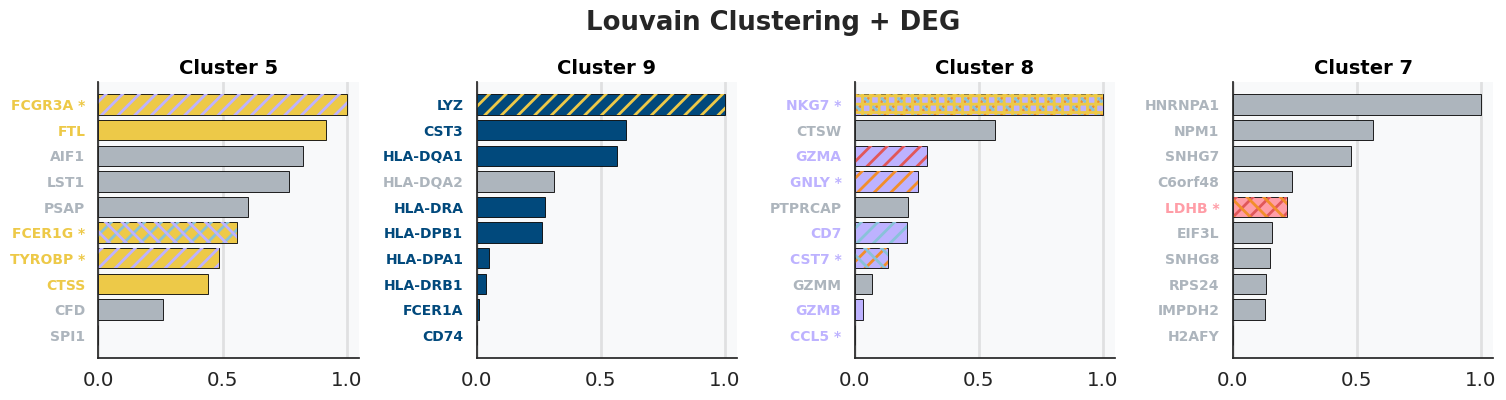

In [287]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
# select 5, 9 and 8 and 7
select_k = [1, 2, 3, 10]
for i, k in enumerate(select_k):
    aligned_k = mapping[k]
    plot_clusterwise_scores_df(louvain_scores, k, aligned_k, df, cell_types_cdict, top_k=10, ax=ax[i], hatch_patterns =  ["//", "\\\\", "++", "..", 'xxxx', '+++++'])
fig.suptitle('Louvain Clustering + DEG', fontweight='bold')
fig.subplots_adjust(wspace=0.45, top=0.8) 
fig.savefig('../figures/louvain_clusterwise_scores.pdf',bbox_inches='tight')

## Global analysis

### Run models

Code to reproduce these results is under `example/PBMC68k.ipynb`.

### Figures

In [14]:
import pandas as pd
benchmark_methods = pd.read_csv('./data/PBMC68k_FI_score_Global_K10.csv', index_col=0)

In [15]:
benchmark_methods.head()

,pbfi,lrp,perm_km,feature,cloc_raw,rampart_raw,impacc
0,0.001124,0.008004,0.000000,0,-0.000157,0.0,0.0
1,0.000308,0.000436,0.000000,1,-0.000196,0.0,0.0
2,0.000837,0.001247,0.000143,2,0.000004,0.0,0.0
3,0.000603,0.002834,0.000000,3,-0.000465,0.0,0.0
4,0.000909,0.000741,0.000000,4,0.000726,0.0,0.0


In [18]:
def make_gene_style_map(
    relevant_markers,
    cell_types_cdict,
    gene_col="Gene",
    cell_type_col="Cell type",
    default_color="#adb5bd",
    multi_hatch="///"
):
    markers = relevant_markers.copy()

    markers[gene_col] = markers[gene_col].astype(str).str.strip()
    markers[cell_type_col] = markers[cell_type_col].astype(str).str.strip()

    markers["color_val"] = (
        markers[cell_type_col]
        .map(cell_types_cdict)
        .fillna(default_color)
    )

    gene_style_map = {}

    for gene, sub in markers.groupby(gene_col):
        sub_unique = sub[[cell_type_col, "color_val"]].drop_duplicates()

        cell_types = sub_unique[cell_type_col].tolist()
        colors = sub_unique["color_val"].tolist()

        is_multi = len(cell_types) > 1

        gene_style_map[gene] = {
            "color": colors[0] if len(colors) else default_color,
            "hatch": multi_hatch if is_multi else None,
            "is_multi": is_multi,
            "cell_types": cell_types,
        }

    return gene_style_map


def plot_top_gene_scores_df(df, score_col, relevant_markers, cell_types_cdict, gene_col="gene_name", marker_gene_col="Gene", marker_cell_type_col="Cell type",
    top_k=10, ax=None, title=None, use_abs=False, normalize_values=True, default_color="#adb5bd", multi_hatch="///"):
    if gene_col not in df.columns:
        raise ValueError(f"{gene_col!r} not found in df.columns")
    if score_col not in df.columns:
        raise ValueError(f"{score_col!r} not found in df.columns")

    plot_df = (df[[gene_col, score_col]].dropna(subset=[gene_col, score_col]).copy())

    if use_abs:
        idx = (plot_df.assign(abs_score=plot_df[score_col].abs()).sort_values("abs_score", ascending=False).drop_duplicates(gene_col).index)
        plot_df = plot_df.loc[idx]
    else:
        plot_df = (plot_df.sort_values(score_col, ascending=False).drop_duplicates(gene_col))

    if use_abs:
        top_df = (plot_df.assign(rank_score=plot_df[score_col].abs()).sort_values("rank_score", ascending=False).head(top_k).sort_values(score_col, ascending=True))
    else:
        top_df = (plot_df.sort_values(score_col, ascending=False).head(top_k).sort_values(score_col, ascending=True))

    genes = top_df[gene_col].astype(str).values
    values = top_df[score_col].astype(float).values

    if normalize_values:
        plot_values = normalize(values)
        xlabel = f"Normalized {score_col}"
    else:
        plot_values = values
        xlabel = score_col

    gene_style_map = make_gene_style_map(relevant_markers=relevant_markers, cell_types_cdict=cell_types_cdict,
        gene_col=marker_gene_col, cell_type_col=marker_cell_type_col, default_color=default_color, multi_hatch=multi_hatch)

    styles = [gene_style_map.get(gene, {"color": default_color, "hatch": None, "is_multi": False, "cell_types": []}) for gene in genes]

    bar_colors = [s["color"] for s in styles]
    bar_hatches = [s["hatch"] for s in styles]

    display_genes = [f"{gene} *" if style["is_multi"] else gene for gene, style in zip(genes, styles)]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    bars = ax.barh(
        display_genes,
        plot_values,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.6
    )

    for bar, hatch in zip(bars, bar_hatches):
        if hatch is not None:
            bar.set_hatch(hatch)

    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

    if title is not None:
        ax.set_title(title, fontsize=14)

    for tick_label, style in zip(ax.get_yticklabels(), styles):
        tick_label.set_color(style["color"])
        tick_label.set_fontsize(10)
        tick_label.set_fontweight("bold")

    return ax

NameError: name 'cell_types_cdict' is not defined

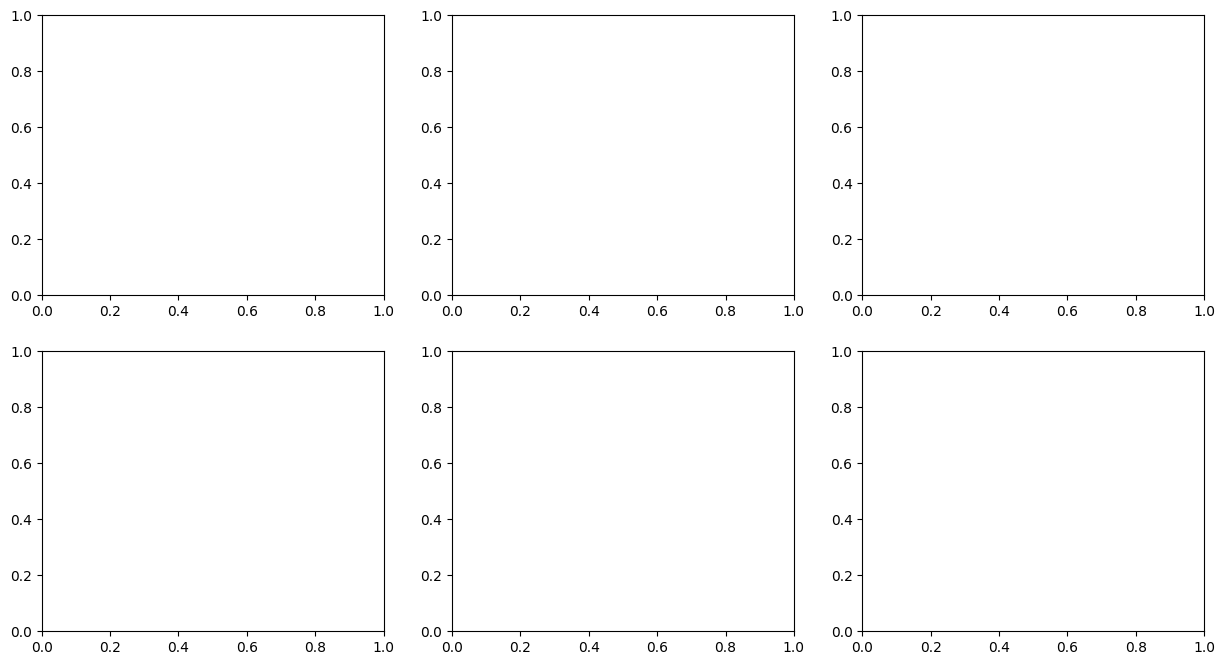

In [22]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 3, figsize=(15,8))
ax = ax.flatten()
method = ['Cluster LOCO-RAMPART\n(HC)', 'Cluster LOCO-MP \n(HC)', 'LRP \n(KMeans)', 'IMPACC \n(HC)', 'PBFI \n(KMeans)', 'PFI \n(KMeans)']
for i, col in enumerate(['rampart_raw','cloc_raw','lrp', 'impacc', 'pbfi', 'perm_km']):
    plot_top_gene_scores_df(
        df=benchmark_methods,
        score_col=col,
        relevant_markers=df,
        cell_types_cdict=cell_types_cdict,
        top_k=10,
        use_abs=False,
        normalize_values=True, 
        ax=ax[i]
    )
    ax[i+1].set_title(method[i])
fig.tight_layout()
# fig.savefig('../figures/global_pbmc_comparison.pdf',
#         bbox_inches="tight",
#         bbox_extra_artists=(legend,),
#         pad_inches=0.05,)

plt.show()

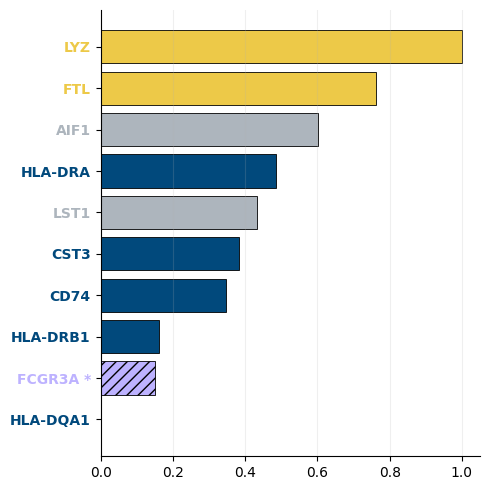

In [82]:
plot_top_gene_scores_df(
    df=benchmark_methods,
    score_col="rampart_raw",
    relevant_markers=df,
    cell_types_cdict=cell_types_cdict,
    top_k=10,
    use_abs=False,
    normalize_values=True,
    multi_hatch="///"
)

plt.tight_layout()
plt.show()

In [351]:
print("hello")

hello


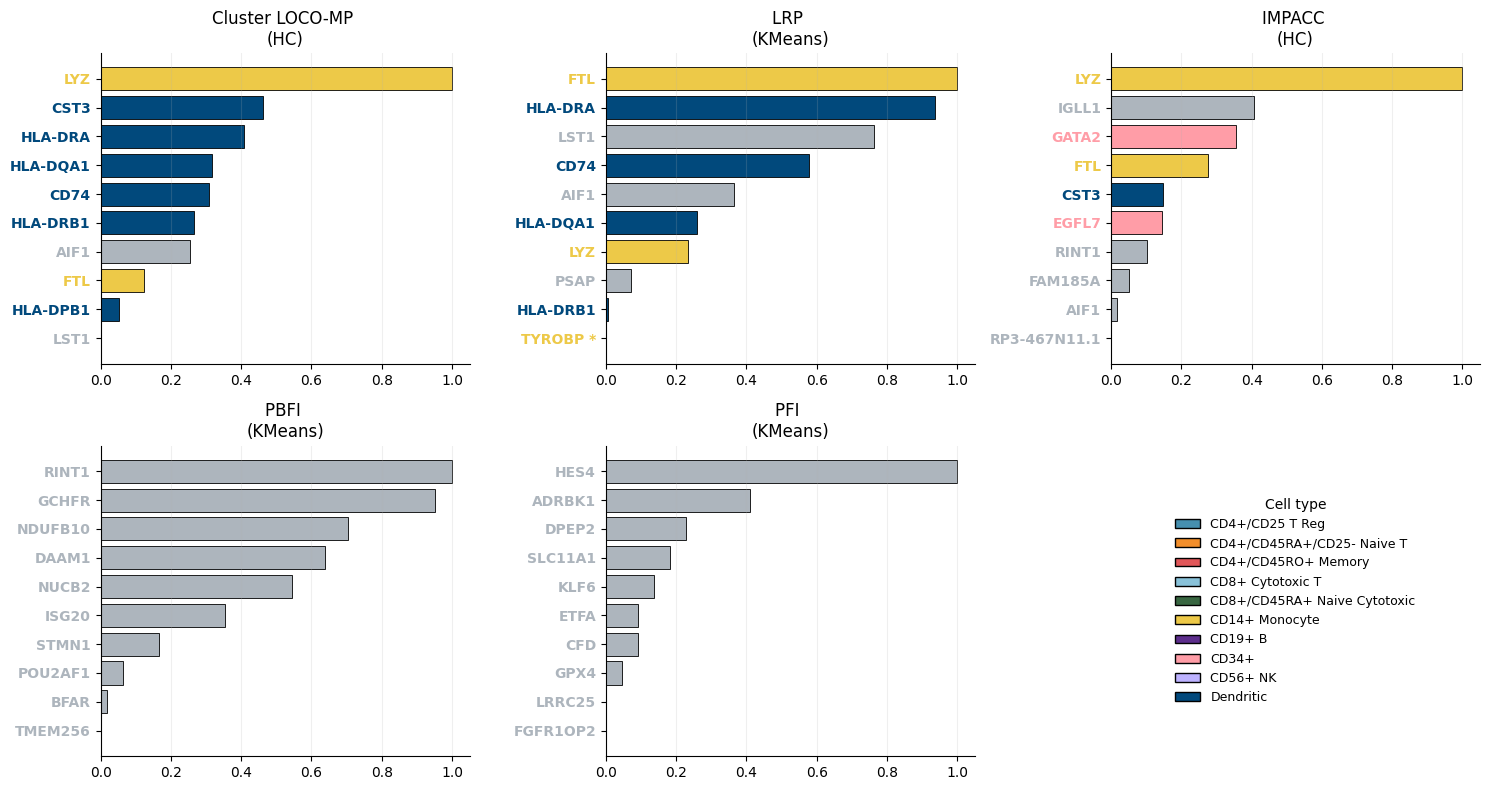

In [83]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.flatten()

method = [
    "Cluster LOCO-MP \n(HC)",
    "LRP \n(KMeans)",
    "IMPACC \n(HC)",
    "PBFI \n(KMeans)",
    "PFI \n(KMeans)"
]

score_cols = ["cloc_raw", "lrp", "impacc", "pbfi", "perm_km"]

for i, col in enumerate(score_cols):
    plot_top_gene_scores_df(
        df=benchmark_methods,
        score_col=col,
        relevant_markers=df,
        cell_types_cdict=cell_types_cdict,
        top_k=10,
        use_abs=False,
        normalize_values=True,
        multi_hatch="//////",
        ax=ax[i]
    )
    ax[i].set_title(method[i])

# Use last subplot for legend
legend_ax = ax[-1]
legend_ax.axis("off")

handles = [
    Patch(facecolor=color, edgecolor="black", label=cell_type)
    for cell_type, color in cell_types_cdict.items()
]

legend_ax.legend(
    handles=handles,
    loc="center",
    frameon=False,
    title="Cell type",
    fontsize=9,
    title_fontsize=10
)

fig.tight_layout()

fig.savefig(
    "../figures/global_pbmc_comparison.pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

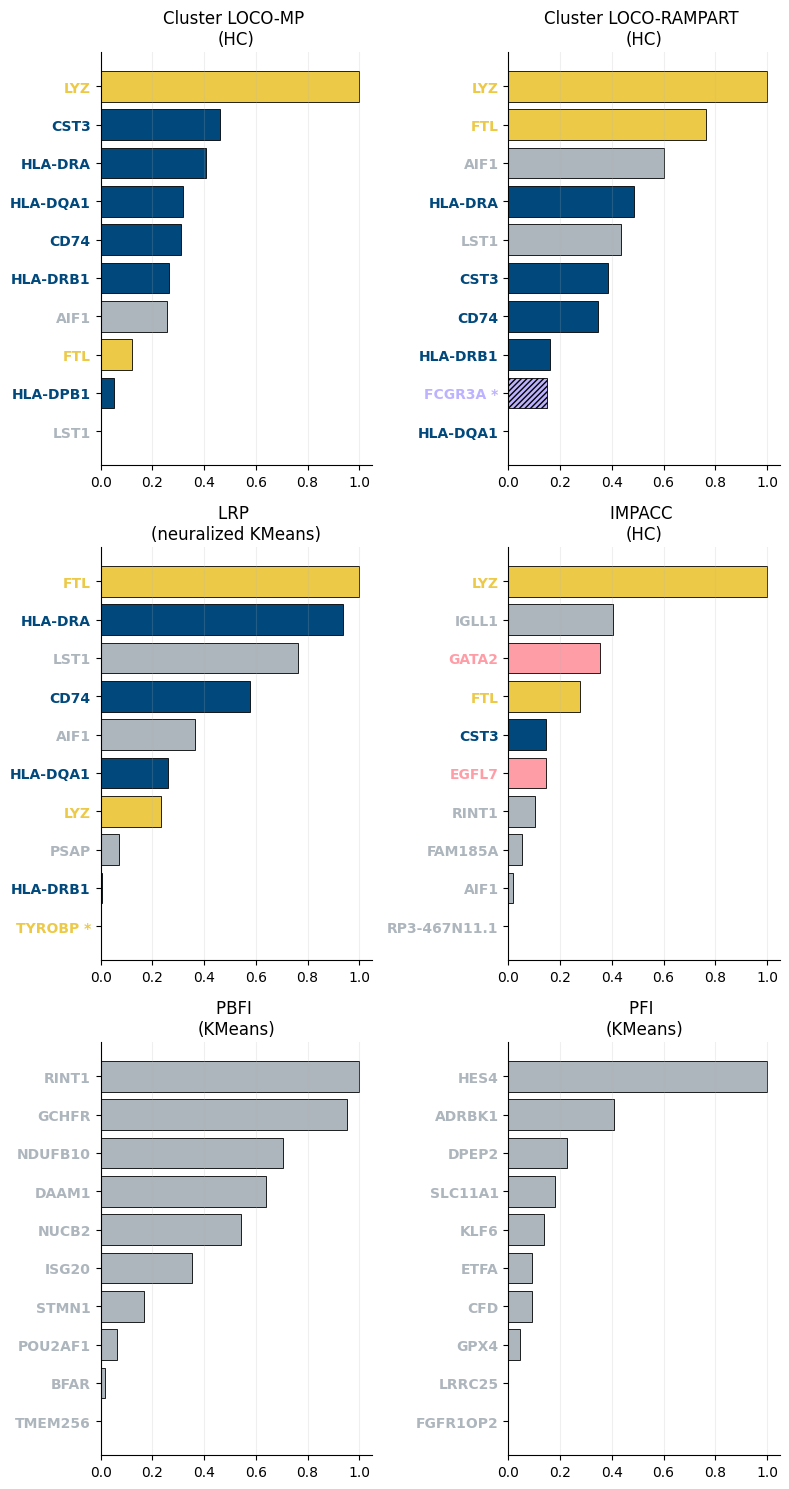

In [88]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(3, 2, figsize=(8, 12))
ax = ax.flatten()

method = [
    "Cluster LOCO-MP \n(HC)",
    "Cluster LOCO-RAMPART \n(HC)", 
    "LRP \n(neuralized KMeans)",
    "IMPACC \n(HC)",
    "PBFI \n(KMeans)",
    "PFI \n(KMeans)"
]

score_cols = ["cloc_raw", "rampart_raw", "lrp", "impacc", "pbfi", "perm_km"]

for i, col in enumerate(score_cols):
    plot_top_gene_scores_df(
        df=benchmark_methods,
        score_col=col,
        relevant_markers=df,
        cell_types_cdict=cell_types_cdict,
        top_k=10,
        use_abs=False,
        normalize_values=True,
        multi_hatch="//////",
        ax=ax[i]
    )
    ax[i].set_title(method[i])

fig.tight_layout()

fig.savefig(
    "../figures/global_pbmc_comparison.pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()